In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Cleaning

In [3]:
workout_df = pd.read_csv("../Fitbit/data/Fitbit_dataset.csv")

In [4]:
workout_df.tail()

,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
14097,14097,18,Male,75.7,1.76,205.0,143.0,67.0,0.62,Yoga,23.3,3.7,4,1,24.3,3.0,0.550725,1.652174,77.5
14098,14098,54,Male,66.4,1.71,162.0,131.0,73.0,0.93,Cardio,15.0,2.7,3,1,22.7,7.0,0.651685,4.561798,281.7
14099,14099,23,Female,74.7,1.52,204.0,161.0,61.0,0.99,Strength,19.3,4.3,3,1,32.5,6.0,0.699301,4.195804,310.3
14100,14100,43,Male,70.8,1.69,171.0,154.0,55.0,1.01,HIIT,12.3,3.9,7,3,24.9,9.5,0.853448,8.107759,579.8
14101,14101,19,Female,87.3,1.60,205.0,156.0,64.0,0.97,Cardio,12.7,3.7,7,3,34.2,7.0,0.652482,4.567376,386.8


In [5]:
workout_df.isnull().sum()

Unnamed: 0                       0
Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
Base_MET                         0
HR_Intensity                     0
Effective_MET                    0
Calories_Burned (kcal)           0
dtype: int64

In [6]:
workout_df.duplicated().sum()

np.int64(0)

In [7]:
workout_df.shape

(14102, 19)

In [8]:
workout_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14102 entries, 0 to 14101
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     14102 non-null  int64  
 1   Age                            14102 non-null  int64  
 2   Gender                         14102 non-null  str    
 3   Weight (kg)                    14102 non-null  float64
 4   Height (m)                     14102 non-null  float64
 5   Max_BPM                        14102 non-null  float64
 6   Avg_BPM                        14102 non-null  float64
 7   Resting_BPM                    14102 non-null  float64
 8   Session_Duration (hours)       14102 non-null  float64
 9   Workout_Type                   14102 non-null  str    
 10  Fat_Percentage                 14102 non-null  float64
 11  Water_Intake (liters)          14102 non-null  float64
 12  Workout_Frequency (days/week)  14102 non-null  int64  
 1

In [9]:
workout_df['Experience_Level'].unique()

array([1, 0, 3, 2])

In [10]:
workout_df['Calories_Burned (kcal)'].describe()

count    14102.000000
mean       279.492866
std        172.858430
min         18.400000
25%        143.200000
50%        251.050000
75%        373.700000
max       1442.400000
Name: Calories_Burned (kcal), dtype: float64

## Renaming Columns

In [11]:
workout_df.rename(columns={
    "Weight (kg)": "Weight",
    "Height (m)": "Height",
    "Session_Duration (hours)": "Session_Duration",
    "Water_Intake (liters)": "Water_Intake",
    "Workout_Frequency (days/week)": "Workout_Frequency",
    "Calories_Burned (kcal)": "Calories_Burned"
}, inplace=True)

In [12]:
workout_df.columns

Index(['Unnamed: 0', 'Age', 'Gender', 'Weight', 'Height', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration', 'Workout_Type', 'Fat_Percentage',
       'Water_Intake', 'Workout_Frequency', 'Experience_Level', 'BMI',
       'Base_MET', 'HR_Intensity', 'Effective_MET', 'Calories_Burned'],
      dtype='str')

In [13]:
workout_df.drop(columns='Unnamed: 0', inplace=True)

In [14]:
workout_df.columns

Index(['Age', 'Gender', 'Weight', 'Height', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration', 'Workout_Type', 'Fat_Percentage',
       'Water_Intake', 'Workout_Frequency', 'Experience_Level', 'BMI',
       'Base_MET', 'HR_Intensity', 'Effective_MET', 'Calories_Burned'],
      dtype='str')

In [15]:
workout_df.head()

,Age,Gender,Weight,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Workout_Type,Fat_Percentage,Water_Intake,Workout_Frequency,Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned
0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7


# Data Visualization

## Outlier Detection

In [16]:
num_cols = workout_df.select_dtypes(include=['int64','float64']).columns

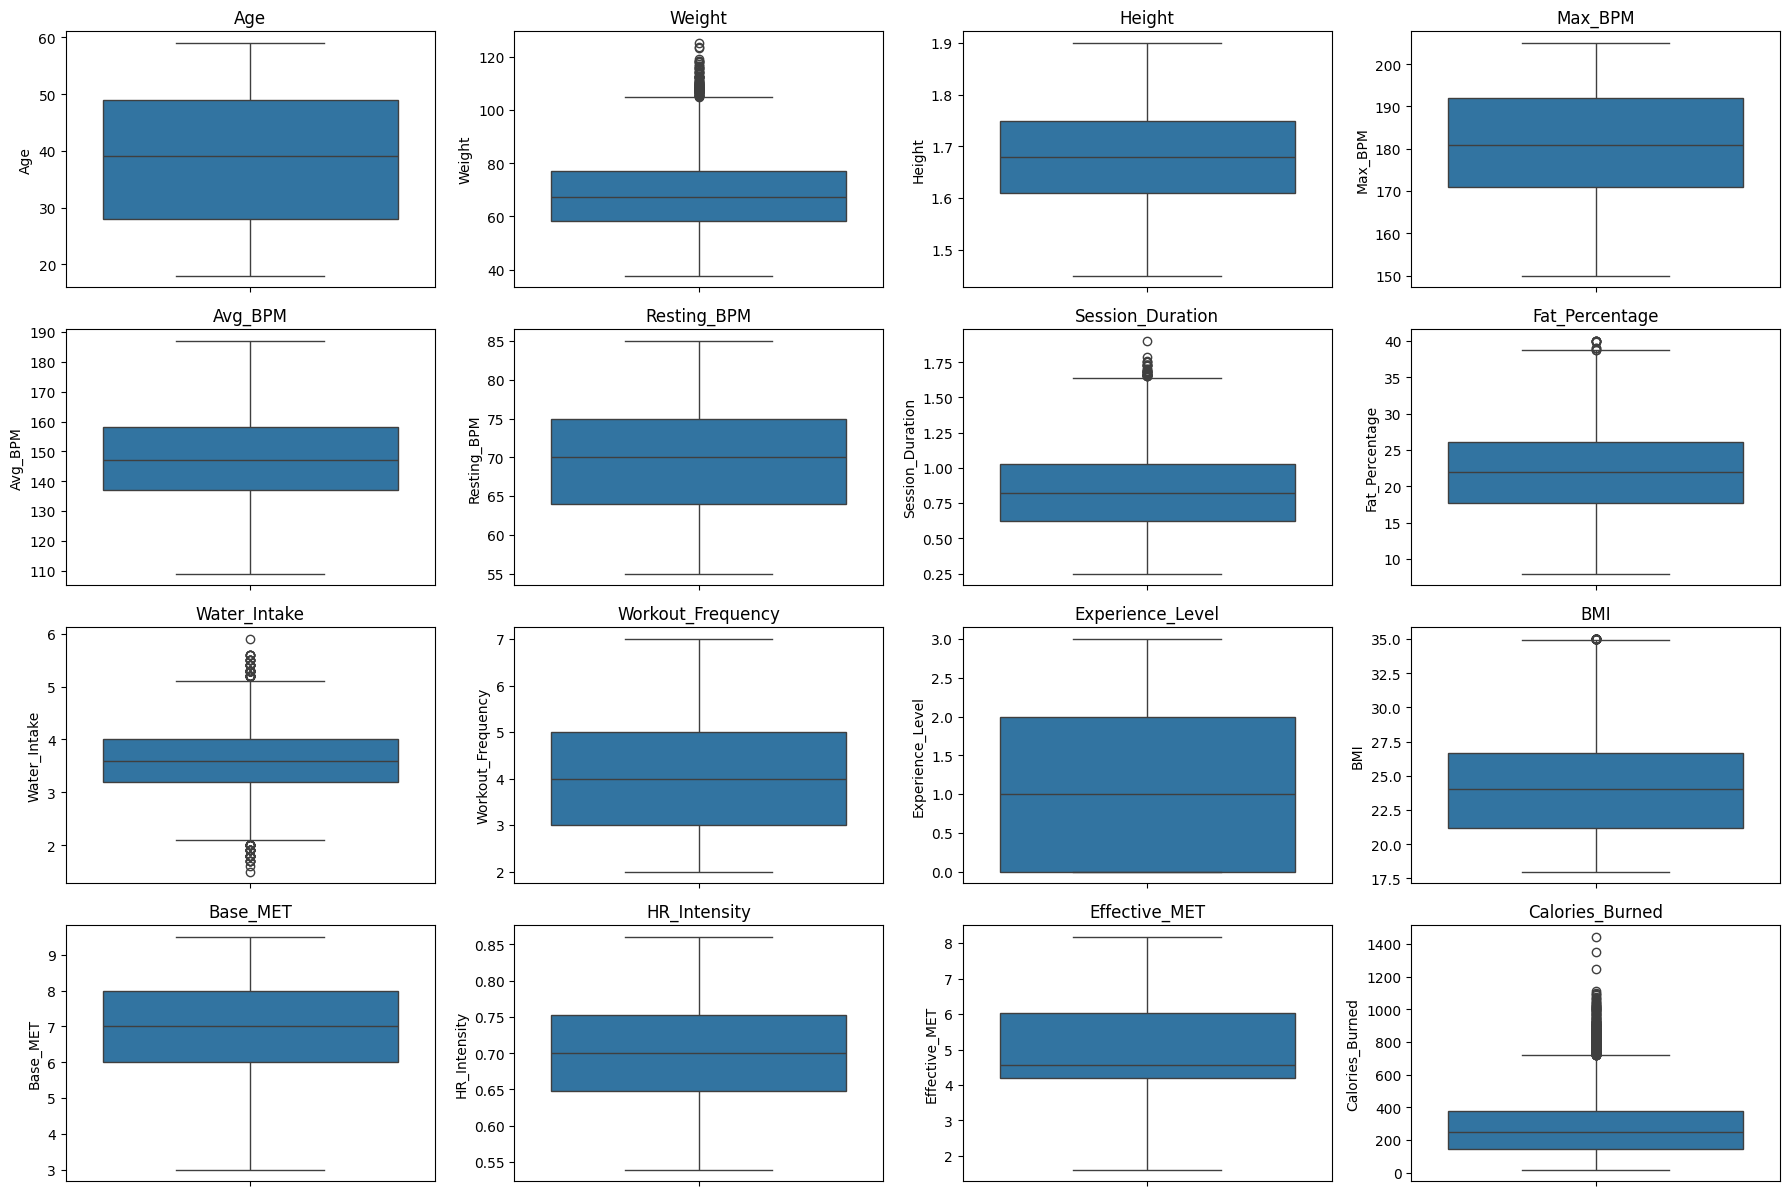

In [17]:
plt.figure(figsize=(18,15))

for i,col in enumerate(num_cols,1):
    plt.subplot(5,4,i)
    sns.boxplot(y=workout_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## Correlation Heatmap

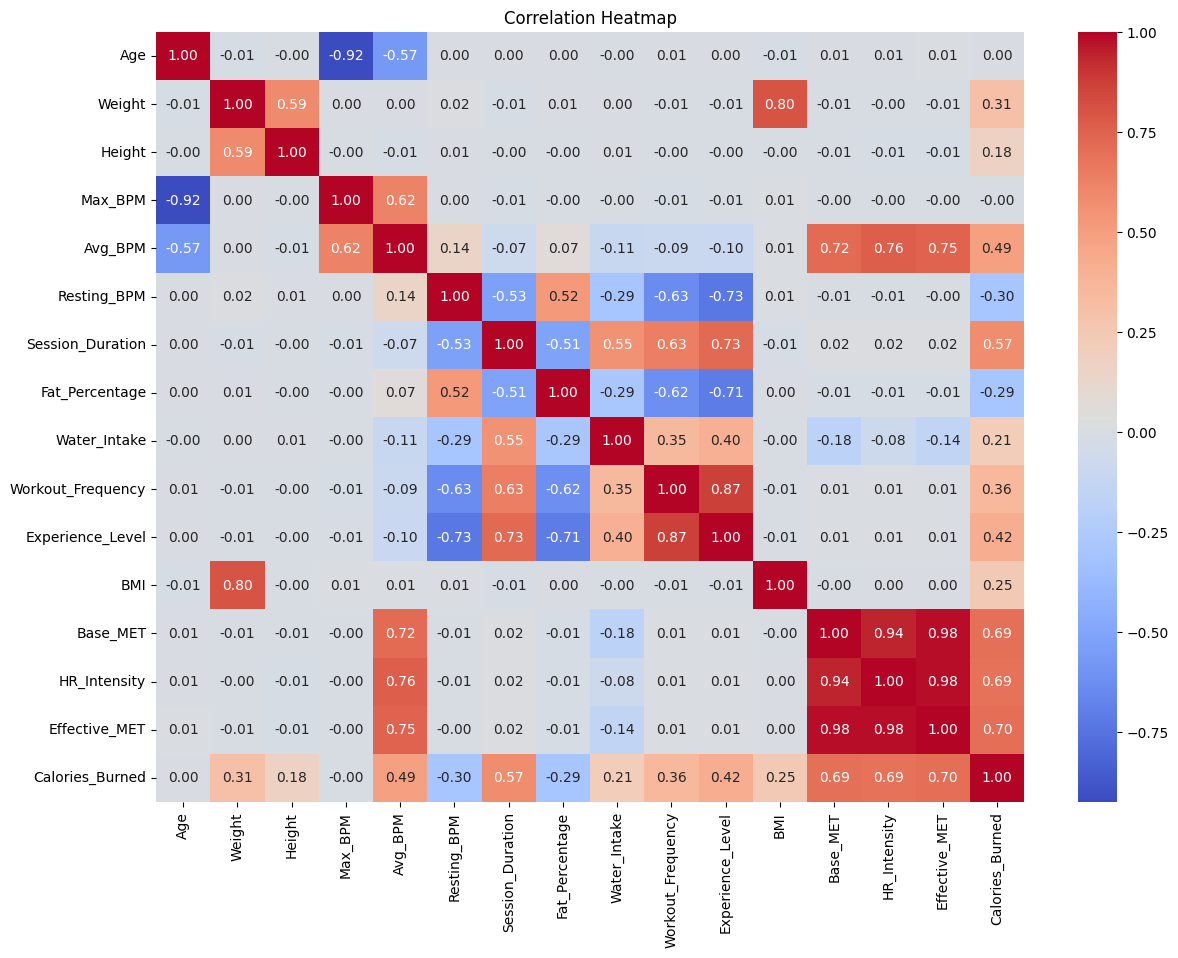

In [18]:
plt.figure(figsize=(14,10))

sns.heatmap(
    workout_df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

## Session Duration vs Calories

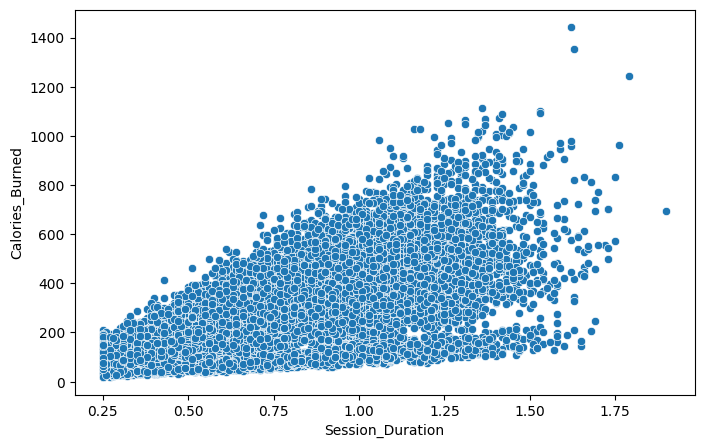

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=workout_df,
    x='Session_Duration',
    y='Calories_Burned'
)
plt.show()

## Calories burned by Workout Type

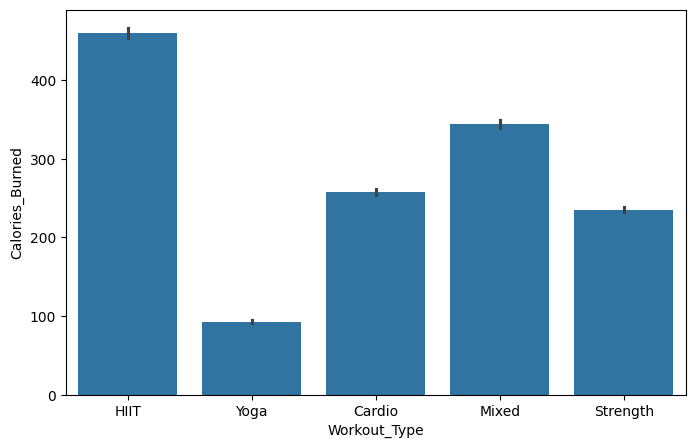

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    data = workout_df,
    x = 'Workout_Type',
    y = 'Calories_Burned'
)
plt.show()

## Calories by Gender

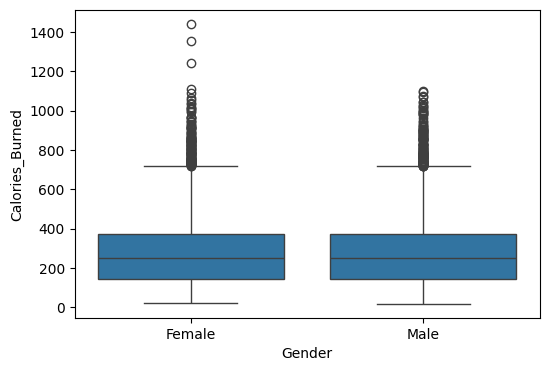

In [21]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=workout_df,
    x='Gender',
    y='Calories_Burned'
)

plt.show()

## Calories by Experience Level

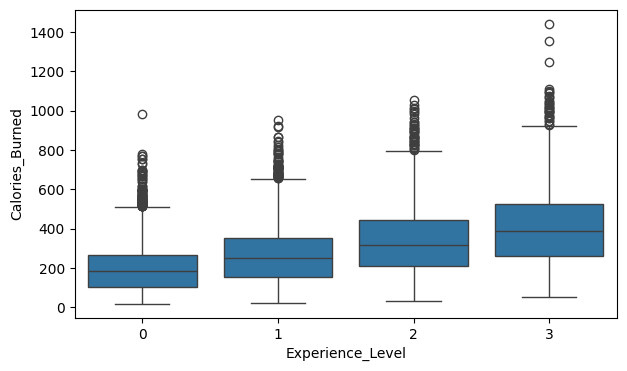

In [22]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=workout_df,
    x='Experience_Level',
    y='Calories_Burned'
)

plt.show()

# Outlier Detection and Capping

## Detect Outliers Using IQR

In [27]:
outliers_data = {}
for col in num_cols:
    q1 = workout_df[col].quantile(0.25)
    q3 = workout_df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((workout_df[col] < lower) | (workout_df[col] > upper)).sum()
    outliers_data[col] = outliers

outliers_df = pd.DataFrame(
    outliers_data.items(),
    columns = ["Feature", "Outliers"]
)

outliers_df

,Feature,Outliers
0,Age,0
1,Weight,93
2,Height,0
3,Max_BPM,0
4,Avg_BPM,0
5,Resting_BPM,0
6,Session_Duration,31
7,Fat_Percentage,10
8,Water_Intake,124
9,Workout_Frequency,0


## Cap the Outliers

In [28]:
for col in num_cols:
    Q1 = workout_df[col].quantile(0.25)
    Q3 = workout_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    workout_df[col] = workout_df[col].clip(lower,upper)

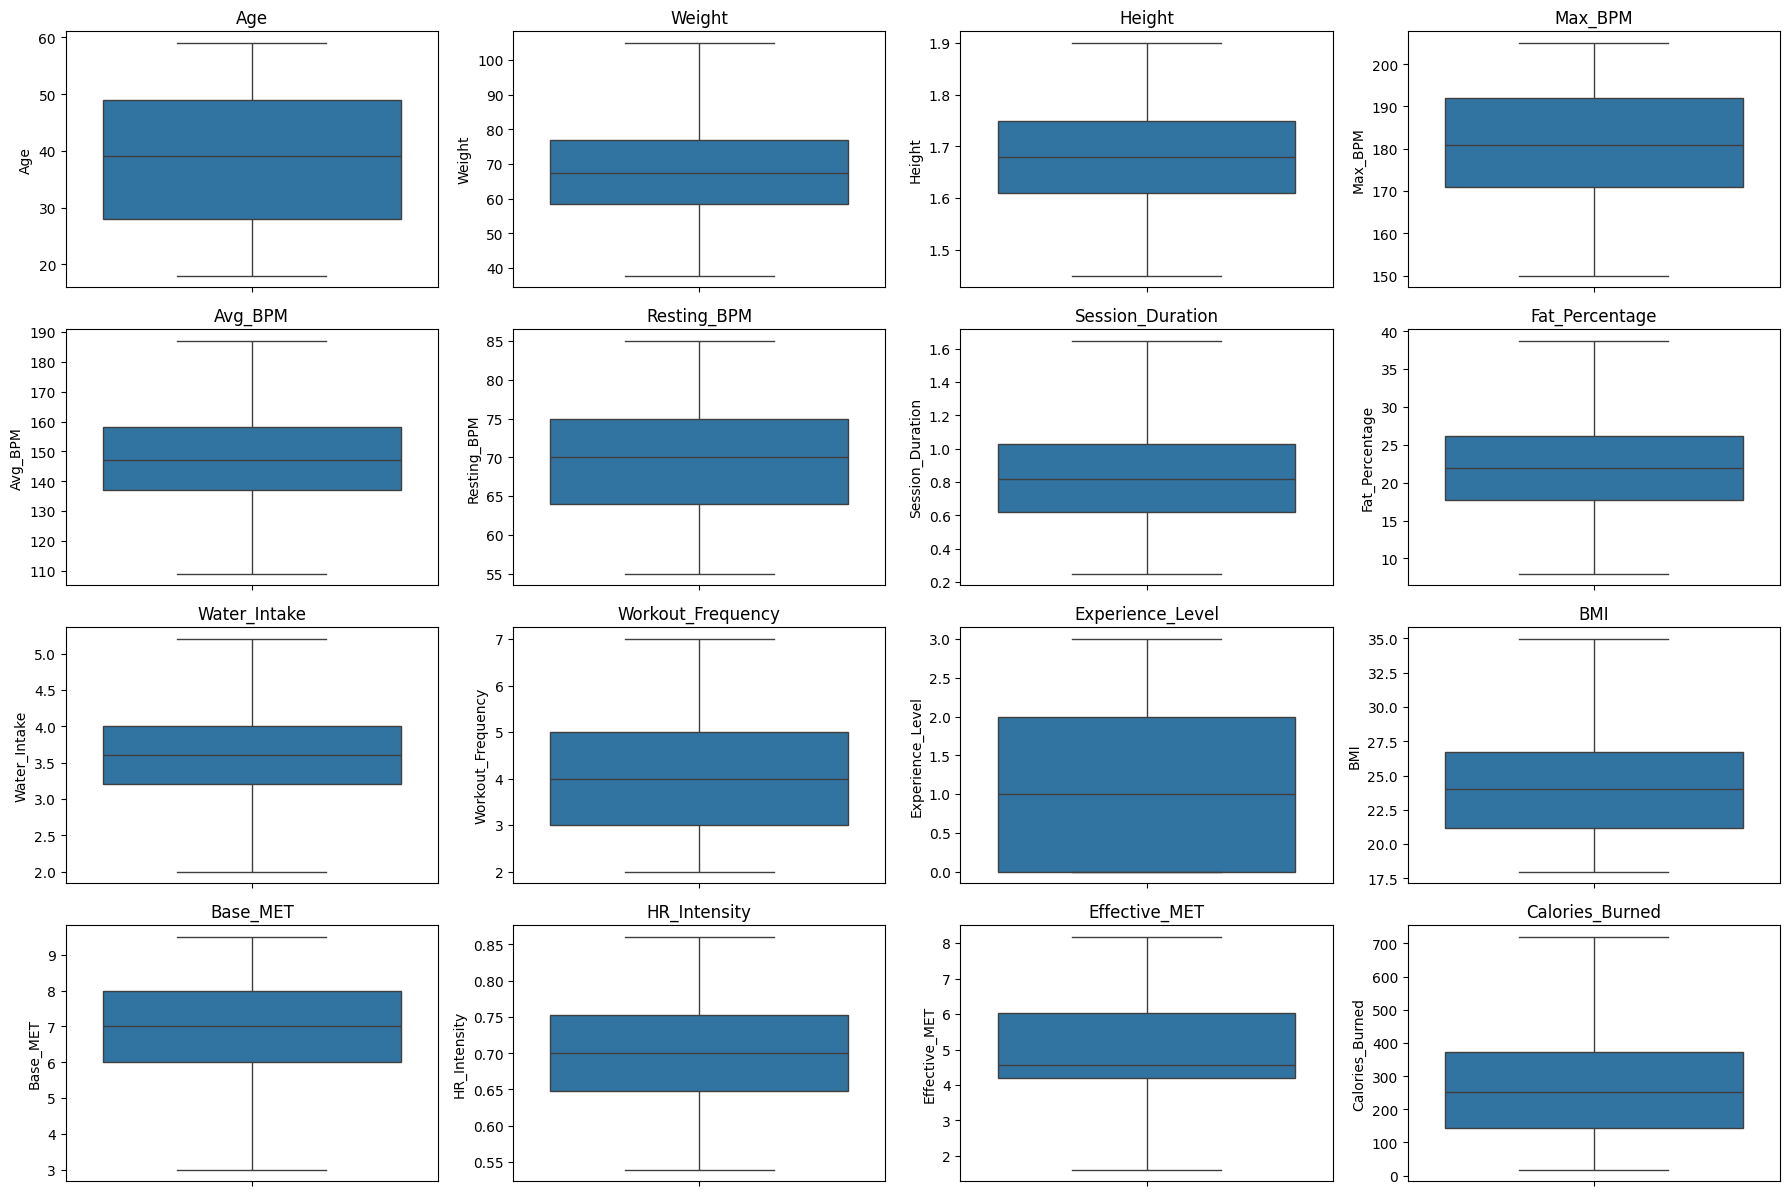

In [29]:
plt.figure(figsize=(18,15))

for i,col in enumerate(num_cols,1):
    plt.subplot(5,4,i)
    sns.boxplot(y=workout_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [40]:
workout_df["Experience_Level"].value_counts().sort_index()

Experience_Level
0    4915
1    4224
2    2888
3    2075
Name: count, dtype: int64

# Encode Categorical Variables

## Label Encoding for Gender Column

In [41]:
workout_df["Gender"] = workout_df["Gender"].map({
    "Male":1,
    "Female":0
})

In [42]:
workout_df['Gender']

0        0
1        1
2        0
3        1
4        1
        ..
14097    1
14098    1
14099    0
14100    1
14101    0
Name: Gender, Length: 14102, dtype: int64

## One-Hot Encoding for Workout_Type

In [43]:
workout_df = pd.get_dummies(
    workout_df,
    columns=["Workout_Type"],
    drop_first=True
)

In [49]:
workout_df.head()

,Age,Gender,Weight,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Fat_Percentage,Water_Intake,...,Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned,Workout_Type_HIIT,Workout_Type_Mixed,Workout_Type_Strength,Workout_Type_Yoga
0,56,0,53.8,1.62,163.0,149.0,71.0,1.01,22.1,3.5,...,1,20.4,9.5,0.847826,8.054348,437.7,1,0,0,0
1,46,1,54.9,1.75,170.0,126.0,73.0,0.25,19.9,3.4,...,0,18.0,3.0,0.546392,1.639175,22.5,0,0,0,1
2,32,0,68.5,1.61,190.0,171.0,60.0,0.33,20.4,2.7,...,1,26.5,9.5,0.853846,8.111538,183.4,1,0,0,0
3,25,1,98.8,1.86,189.0,135.0,69.0,0.78,30.3,4.4,...,0,28.5,3.0,0.550000,1.650000,127.2,0,0,0,1
4,38,1,95.5,1.71,176.0,138.0,66.0,0.55,23.7,2.2,...,0,32.5,7.0,0.654545,4.581818,240.7,0,0,0,0


# Save cleaned dataset

In [50]:
workout_df.to_csv("../Fitbit/data/fitbit_cleaned.csv", index=False)